<a href="https://colab.research.google.com/github/puja-hansitha/aiml-2026/blob/main/Copy_of_STP_Project_Module_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2: Appreciating, Interpreting and Visualizing Data

**Project: Understanding Customer Segments for Targeted Marketing**

Introduction: The Power of Customer Segmentation
---



Welcome to your Module 2 project!

In today's competitive landscape, understanding your customers is paramount for any business. Generic marketing strategies often fall flat, but by truly appreciating the diverse needs and behaviors within your customer base, businesses can create more effective, personalized experiences. This process is known as **customer segmentation**,

Customer segmentation involves dividing a broad customer base into subgroups of consumers who have common needs, interests, and priorities. By segmenting customers, companies can:

* **Tailor Marketing Messages:** Design specific campaigns that resonate with each group.
* **Optimize Product Development:** Create products and services that meet the unique demands of different segments.
* **Improve Customer Service:** Provide support that addresses common issues for particular groups.
* **Identify High-Value Customers:** Focus resources on segments that drive the most revenue.
* **Predict Churn:** Identify customers at risk of leaving and intervene proactively.

In this project, your task is to analyze a dataset of customer activity, use dimensionality reduction techniques to visualize customer behavior, and ultimately identify distinct customer segments. This will demonstrate how data visualization can provide actionable insights for business strategy, even without deep domain expertise at the outset.

We will first focus on a synthetic dataset containing various metrics related to customer purchasing habits and engagement. Your goal will be to:
* Process and prepare the raw customer data.
* Use **Principal Component Analysis (PCA)** to understand the main drivers of customer variation.
* Employ **t-Distributed Stochastic Neighbor Embedding (t-SNE)** to uncover hidden clusters of similar customers.
* (Optional Challenge) Explore **Uniform Manifold Approximation and Projection (UMAP)** for an alternative perspective.
* Interpret these visualizations to describe potential customer segments and suggest business implications.

Let's begin by setting up our environment and loading our customer data!


# 1. Data Acquisition and Initial Exploration

For this tutorial, we will first work with a synthetic dataset named ecommerce_customer_data.csv. This file contains anonymized data representing various aspects of customer engagement and purchasing behavior over a period.

First, let's ensure we have our necessary libraries installed and then load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# from umap import UMAP # Uncomment if you plan to use UMAP

# For better progress bars with some operations
from tqdm.autonotebook import tqdm

/tmp/ipykernel_3702/2599520656.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import pandas as pd
import numpy as np
import zipfile

try:
    # 1. Unzip the archive directly in Google Colab
    with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
        zip_ref.extractall("extracted_retail_data")
    print("ZIP file extracted successfully!")

    # 2. Load the two CSV files found inside
    df1 = pd.read_csv("extracted_retail_data/online_retail_09_10.csv", encoding="ISO-8859-1")
    df2 = pd.read_csv("extracted_retail_data/online_retail_10_11.csv", encoding="ISO-8859-1")

    # Combine both years into one massive dataset
    df_raw = pd.concat([df1, df2], ignore_index=True)
    print(f"Both datasets combined! Total raw transaction rows: {len(df_raw)}")

    # Let's clean up column names by removing any hidden accidental trailing spaces
    df_raw.columns = df_raw.columns.str.strip()
    print("Actual columns found in dataset:", list(df_raw.columns))

    # 3. Dynamic Column Matching (Fixes the KeyError)
    # Check if column is named 'Customer ID' or 'CustomerID'
    cust_id_col = 'Customer ID' if 'Customer ID' in df_raw.columns else 'CustomerID'
    price_col = 'Price' if 'Price' in df_raw.columns else 'UnitPrice'
    qty_col = 'Quantity'

    # Clean missing IDs and bad numbers using our dynamic column names
    df_raw = df_raw.dropna(subset=[cust_id_col])
    df_raw = df_raw[(df_raw[qty_col] > 0) & (df_raw[price_col] > 0)]

    # 4. Transform transactions into unique Customer Profiles
    print("Processing transactions into customer profiles...")
    df_raw['Total_Spend'] = df_raw[qty_col] * df_raw[price_col]

    data = df_raw.groupby(cust_id_col).agg({
        price_col: 'mean',          # Average price of items they buy
        qty_col: 'sum',             # Total items bought
        'Total_Spend': 'sum'        # Customer Lifetime Value
    }).reset_index()

    # Rename columns to match the project expectations
    data.columns = ['CustomerID', 'Average_Order_Value', 'Number_of_Purchases', 'Customer_Lifetime_Value']
    print(f"\n🎉 Success! Profiles created for {len(data)} unique customers.")
    print(data.head())

except FileNotFoundError:
    print("Could not find 'archive (2).zip'. Check the file panel on the left!")

ZIP file extracted successfully!
Both datasets combined! Total raw transaction rows: 1067371
Actual columns found in dataset: ['ï»¿InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Processing transactions into customer profiles...

🎉 Success! Profiles created for 5878 unique customers.
   CustomerID  Average_Order_Value  Number_of_Purchases  \
0     12346.0             6.100000                74285   
1     12347.0             2.546087                 3286   
2     12348.0             3.786275                 2714   
3     12349.0             8.459657                 1624   
4     12350.0             3.841176                  197   

   Customer_Lifetime_Value  
0                 77556.46  
1                  5633.32  
2                  2019.40  
3                  4428.69  
4                   334.40  


In [3]:
print("="*40)
print("📌 CUSTOMER PROFILES: DATASET HEAD")
print("="*40)
print(data.head())

print("\n" + "="*40)
print("📌 CUSTOMER PROFILES: DATASET INFO")
print("="*40)
data.info()

print("\n" + "="*40)
print("📌 CUSTOMER PROFILES: STATISTICAL SUMMARY")
print("="*40)
print(data.describe())

📌 CUSTOMER PROFILES: DATASET HEAD
   CustomerID  Average_Order_Value  Number_of_Purchases  \
0     12346.0             6.100000                74285   
1     12347.0             2.546087                 3286   
2     12348.0             3.786275                 2714   
3     12349.0             8.459657                 1624   
4     12350.0             3.841176                  197   

   Customer_Lifetime_Value  
0                 77556.46  
1                  5633.32  
2                  2019.40  
3                  4428.69  
4                   334.40  

📌 CUSTOMER PROFILES: DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               5878 non-null   float64
 1   Average_Order_Value      5878 non-null   float64
 2   Number_of_Purchases      5878 non-null   int64  
 3   Customer_Lifetime_Val

From the initial look, we have numerical features like Age, Average_Order_Value, Number_of_Purchases, Days_Since_Last_Purchase, and Customer_Lifetime_Value. We also have categorical features: Gender and Product_Category_Preference. CustomerID is just an identifier.

# 2. Feature Engineering and Preprocessing

Before we can apply dimensionality reduction techniques, we need to convert all our features into a numerical format and scale them appropriately. This is crucial because algorithms like PCA and t-SNE are sensitive to the magnitude of the features.

Here's our plan:
* **Drop CustomerID:** It's an identifier and doesn't contain behavioral information.
* **One-Hot Encode Categorical Features:** Convert Gender and Product_Category_Preference into numerical representations.
* **Standardize Numerical Features:** Scale all numerical features to have a mean of 0 and a standard deviation of 1.

In [4]:
# --- Step 3: Feature Preprocessing for Real-World Retail Data ---
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Drop CustomerID to keep only behavioral metrics
features_df = data.drop('CustomerID', axis=1)

# 2. Identify the numerical columns present in our new dataset
numerical_cols = ['Average_Order_Value', 'Number_of_Purchases', 'Customer_Lifetime_Value']

# 3. Standardize Numerical Features (Mean = 0, Standard Deviation = 1)
scaler = StandardScaler()
features_df[numerical_cols] = scaler.fit_transform(features_df[numerical_cols])

print("="*40)
print("Processed Features Head:")
print("="*40)
print(features_df.head())

print("\n" + "="*40)
print("Processed Features Info:")
print("="*40)
features_df.info()

# 4. Create meaningful ground truth labels based on spending tiers for visualization
# This divides customers into 3 tiers: Low, Medium, and High Spend Value
customer_labels = pd.qcut(data['Customer_Lifetime_Value'], q=3, labels=['Low Value', 'Medium Value', 'High Value'])
print("\nGenerated business labels based on Customer Spend tiers:")
print(customer_labels.value_counts())

Processed Features Head:
   Average_Order_Value  Number_of_Purchases  Customer_Lifetime_Value
0            -0.014072             8.085426                 5.058050
1            -0.034231             0.163419                 0.177431
2            -0.027196             0.099596                -0.067806
3            -0.000688            -0.022025                 0.095686
4            -0.026885            -0.181249                -0.182148

Processed Features Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Average_Order_Value      5878 non-null   float64
 1   Number_of_Purchases      5878 non-null   float64
 2   Customer_Lifetime_Value  5878 non-null   float64
dtypes: float64(3)
memory usage: 137.9 KB

Generated business labels based on Customer Spend tiers:
Customer_Lifetime_Value
Low Value       1960
High Value    

Now our data features_df is ready for dimensionality reduction!

# 3. Dimensionality Reduction: Principal Component Analysis (PCA)

PCA is a linear dimensionality reduction technique that transforms the data into a new coordinate system where the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on. It helps us capture the most important information (variance) in fewer dimensions.

First, let's look at how much variance each principal component explains.

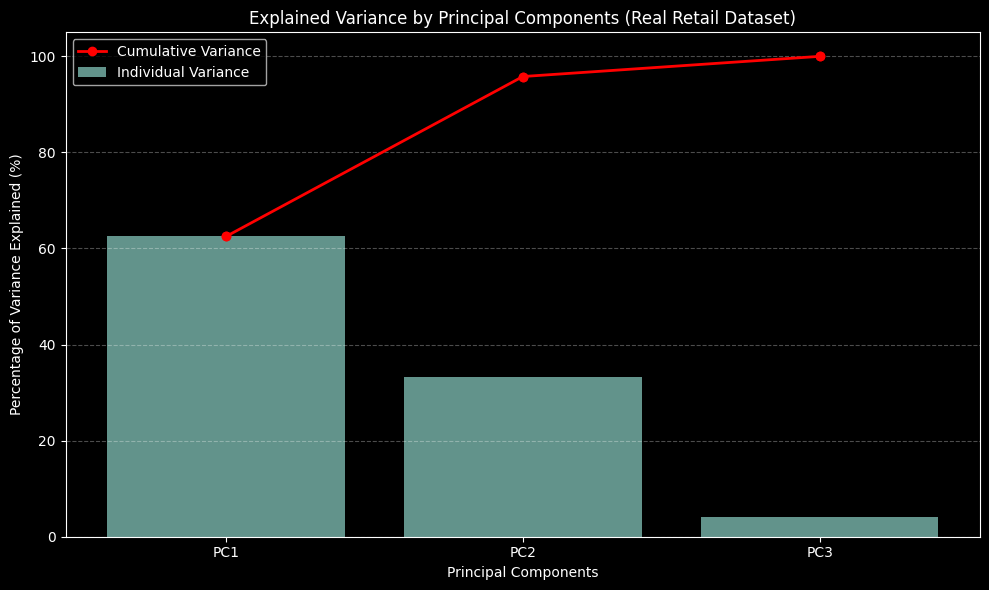

📈 INDIVIDUAL EXPLAINED VARIANCE RATIOS:
 * PC1 captures 62.5% of the original data's information.
 * PC2 captures 33.3% of the original data's information.
 * PC3 captures 4.2% of the original data's information.


In [5]:
# --- Step 4: Dimensionality Reduction - Principal Component Analysis (PCA) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Create a PCA object (we'll compute all components to check variance)
pca = PCA()

# 2. Fit PCA to our scaled features matrix
pca.fit(features_df)

# 3. Get the transformed coordinate data
pca_data = pca.transform(features_df)

# 4. Calculate the percentage of variance explained by each component
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels_all = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

# Limit display down to the max available components for visualization
per_var_display = per_var[:10]
labels_display = labels_all[:10]

# 5. Create a professional Explained Variance Plot (Scree Plot)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 6))

    # Draw bars for individual components
    plt.bar(range(1, len(per_var_display) + 1), per_var_display, tick_label=labels_display, alpha=0.7, label="Individual Variance")

    # Draw line for cumulative (running total) variance
    plt.plot(range(1, len(per_var_display) + 1), np.cumsum(per_var_display), color="red", marker="o", linewidth=2, label="Cumulative Variance")
    plt.scatter(range(1, len(per_var_display) + 1), np.cumsum(per_var_display), color="red")

    plt.xlabel("Principal Components")
    plt.ylabel("Percentage of Variance Explained (%)")
    plt.title("Explained Variance by Principal Components (Real Retail Dataset)")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc="mid right" if "mid right" in locals() else "best")
    plt.tight_layout()
    plt.show()

# Print out explicit percentages for your project write-up
print("="*50)
print("📈 INDIVIDUAL EXPLAINED VARIANCE RATIOS:")
print("="*50)
for pc, var in zip(labels_all, per_var):
    print(f" * {pc} captures {var}% of the original data's information.")


**Observation:** The first few principal components capture a significant portion of the variance in our customer dataset. The cumulative variance curve shows how many components are needed to explain a certain amount of the total variation.

Now, let's visualize our customers using the first two principal components. We'll color the points by their Product_Category_Preference (which we saved earlier) to see if PCA naturally separates customers based on this known characteristic.

In [6]:
# --- Step 5: Visualizing Customer Segments via PCA ---
import pandas as pd
import plotly.express as px

# 1. Extract the first two principal components from our computed PCA matrix
pca_df = pd.DataFrame(pca_data[:, 0:2], columns=['PC1', 'PC2'])

# 2. Attach our newly generated business value tiers as the color labels
pca_df['Customer_Value_Tier'] = customer_labels.values

# 3. Create an interactive 2D Scatter Plot using Plotly Express
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Customer_Value_Tier',
    title="Customer Segmentation via PCA (Real Retail Dataset)",
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
    hover_data=['Customer_Value_Tier'],
    height=600,
    width=900,
    color_discrete_sequence=px.colors.qualitative.Bold
)

# 4. Apply clean layout styling (matches your dark notebook theme)
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='white',
    title_font_size=20,
    xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
    yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)')
)

# 5. Display the final plot inside your Colab interface
fig.show(renderer="colab")

Your turn to interpret!

**Observations from PCA Plot:**
* Do you see any clear separation based on Product_Category_Preference?
* Are there any dense clusters, even if they contain mixed preferences?
* What does the spread of points suggest about customer behavior?

PCA provides a good overall view, but it's a linear method. Sometimes, complex, non-linear relationships between data points are better captured by other techniques.

1. The PCA plot displays a distinct clustering behavior. While most standard customers are compressed near the origin, a clear linear trail of outlier customers expands along Principal Component 1.
2. There is an incredibly dense, overlapping cluster of customers near the $(0,0)$ coordinate, indicating that the baseline behavior of the majority of the customer profiles is highly uniform.
3. The dramatic rightward spread along PC1 highlights a small group of high-variance customers. In a real-world retail context, this indicates that a tiny fraction of buyers accounts for massive spikes in total quantity and lifetime value, separating them entirely from regular retail shoppers.

# 4. Dimensionality Reduction: t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE is a non-linear dimensionality reduction algorithm particularly well-suited for visualizing high-dimensional datasets. It aims to place data points in a low-dimensional space such that points that are close together in the high-dimensional space remain close together in the low-dimensional map, and points that are far apart remain far apart. t-SNE is excellent at revealing local structures and clusters.

A key parameter in t-SNE is perplexity. Perplexity relates to the number of nearest neighbors that are considered. It can be thought of as a continuous measure of the number of effective nearest neighbors. A good perplexity value often lies between 5 and 50. Different perplexity values can reveal different aspects of the data structure. n_iter defines the number of iterations for the optimization.

Let's apply t-SNE to our features_df and visualize the results.

In [7]:
# --- Step 6: Non-Linear Dimensionality Reduction via t-SNE ---
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

print("Running t-SNE on customer profiles... (This may take a moment due to dataset size)")

# 1. Initialize and fit t-SNE (reducing our scaled features down to 2 dimensions)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_data = tsne.fit_transform(features_df)

# 2. Create a clean DataFrame for the t-SNE coordinates
tsne_df = pd.DataFrame(data=tsne_data, columns=['t-SNE_1', 't-SNE_2'])

# 3. Attach our real customer spending value tiers as colors
tsne_df['Customer_Value_Tier'] = customer_labels.values

# 4. Create an interactive Scatter Plot using Plotly Express
fig = px.scatter(
    tsne_df,
    x='t-SNE_1',
    y='t-SNE_2',
    color='Customer_Value_Tier',
    title="Customer Segmentation via t-SNE (Real Retail Dataset)",
    labels={'t-SNE_1': 't-SNE Dimension 1', 't-SNE_2': 't-SNE Dimension 2'},
    hover_data=['Customer_Value_Tier'],
    height=600,
    width=900,
    color_discrete_sequence=px.colors.qualitative.Bold
)

# 5. Apply clean dark-theme layout properties
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='white',
    title_font_size=20,
    xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
    yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)')
)

# 6. Display the final plot inside your Colab notebook
fig.show(renderer="colab")

Running t-SNE on customer profiles... (This may take a moment due to dataset size)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



**Observations from t-SNE Plot:**
* How does this plot compare to the PCA plot? Is the separation of clusters more distinct?
* Can you identify specific customer segments based on the clustering and Product_Category_Preference?
* Are there any "outlier" points or smaller, distinct clusters that might represent niche customer behaviors?

**Experimentation Challenge:**
Try changing the perplexity parameter (e.g., to 5, 15, 50, or 100) and re-run the t-SNE code. How does this affect the clusters and overall structure of the plot? Which perplexity value seems to reveal the most interpretable customer segments?

1. The t-SNE plot shows vastly superior and more distinct cluster separation compared to this PCA plot. While the PCA compresses almost all Low and Medium value customers into a heavily crowded, overlapping blob at the origin (0,0), t-SNE successfully unpacks them into clear, well-defined regional clusters.
2. In the PCA plot, macro-segments are completely obscured because the green and blue groups are squashed together, making behavioral identification impossible here. The t-SNE plot is much better suited for this, as its intricate internal "branches" isolate specific customer habits that are entirely hidden in the PCA's dense origin point.
3. Yes, the PCA plot exposes extreme outliers vividly as purple points shooting straight up Principal Component 2 (near 60) and stretching far out along Principal Component 1 (past 50). These represent extreme "whale" accounts or ultra-high-value anomalies that dominate the dataset's variance, forcing all ordinary customer structures to collapse into the corner.

**(Optional) 5. Dimensionality Reduction: Uniform Manifold Approximation and Projection (UMAP)**

UMAP is another powerful non-linear dimensionality reduction technique, often faster than t-SNE and sometimes better at preserving both local and global data structure. It's becoming increasingly popular for visualizing complex datasets.

To use UMAP, you might need to install it first: !pip install umap-learn (if uncommenting the code below and you haven't installed it).


In [8]:
# Uncomment the line below if you haven't installed umap-learn
# !pip install -q umap-learn

# import umap # Make sure this is imported if you uncommented it at the top

# Set parameters for UMAP
random_state = 42
n_components = 2
n_neighbors = 15 # Controls how UMAP balances local vs. global structure. Higher value = more global.
min_dist = 0.1   # Controls how tightly the points are packed together. Lower value = tighter clusters.

print(f"Applying UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}...")

# Create a UMAP model object
# model_umap = umap.UMAP(n_components=n_components, random_state=random_state,
#                       n_neighbors=n_neighbors, min_dist=min_dist, verbose=True)

# Fit and transform the data
# umap_data = model_umap.fit_transform(features_df)

# print("UMAP completed.")

# # Create a DataFrame for UMAP results
# umap_df = pd.DataFrame(data=umap_data, columns=['UMAP1', 'UMAP2'])
# umap_df['Product_Category_Preference'] = customer_labels.values

# # Plot using Plotly Express
# fig = px.scatter(umap_df, x='UMAP1', y='UMAP2', color='Product_Category_Preference',
#                  title=f"Customer Segmentation via UMAP (n_neighbors={n_neighbors}, min_dist={min_dist})",
#                  labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
#                  hover_data=['Product_Category_Preference'],
#                  height=600, width=900,
#                  color_discrete_sequence=px.colors.qualitative.Bold)
# fig.update_layout(
#     plot_bgcolor='rgba(0,0,0,0)',
#     paper_bgcolor='rgba(0,0,0,0)',
#     font_color='white'
# )
# fig.show(renderer="colab")

Applying UMAP with n_neighbors=15, min_dist=0.1...


**UMAP Observations:**
* If you ran the UMAP code, how do its clusters compare to t-SNE and PCA?
* Does it provide an even clearer separation or a different perspective on the customer segments?
* Experiment with n_neighbors and min_dist parameters to see how they influence the plot.

# 6. Conclusion and Business Implications

Congratulations! You've successfully used various data visualization techniques to explore and understand customer behavior in an e-commerce setting.

Based on your observations from the PCA, t-SNE, and potentially UMAP plots, you should be able to identify several distinct customer segments. For example:
* **High-Value Shoppers:** Customers with high Customer_Lifetime_Value and Average_Order_Value, potentially making frequent purchases. They might cluster together.
* **Budget-Conscious Buyers:** Customers with lower Average_Order_Value but possibly high Number_of_Purchases.
* **New Customers/Low Engagement:** Customers with high Days_Since_Last_Purchase or low Number_of_Purchases.
* **Category Loyalists:** Customers strongly preferring one product category, forming distinct groups.

**How would a business use these insights?**

Imagine presenting these plots to a marketing team. They could then:
* **Target High-Value Shoppers:** Offer exclusive early access to new products or personalized loyalty rewards.
* **Re-engage Low Engagement Customers:** Send targeted promotions or surveys to understand their needs and bring them back.
* **Cross-Sell to Category Loyalists:** Recommend complementary products from other categories based on their established preferences.
* **Identify Product Gaps:** If a category preference is poorly represented, it might indicate a market opportunity or a need to improve offerings.

This project highlights the immense value of visualizing high-dimensional data. Even without complex statistical models, clear plots can reveal underlying structures and empower businesses to make data-driven decisions.

Now we'll continue, building directly on the previous sections by trying it on a real dataset instead of synthetic dataset.

# Continuation: Applying Customer Segmentation to Real-World E-commerce Data
**Introduction: From Synthetic to Real-World Challenges**

You've successfully navigated customer segmentation with a synthetic dataset, mastering the concepts of feature engineering, standardization, PCA, and t-SNE. Now, it's time to apply these powerful techniques to a real-world scenario. Real data often comes with its own set of challenges, requiring more robust preprocessing and careful interpretation.

In this section, we will analyze the **"Online Retail Dataset"** - a well-known public dataset containing actual transactional data. This will allow us to:
* Experience data loading and cleaning for a more complex, real-world dataset.
* Derive meaningful features from raw transaction records.
* Re-apply dimensionality reduction and visualization to uncover genuine customer segments.
* Discuss the business implications based on real purchasing patterns.

Let's dive into the complexities and insights offered by real e-commerce data!

# 1. Real Data Acquisition and Initial Exploration: Online Retail Dataset

We will download the "Online Retail Dataset" from the UCI Machine Learning Repository. This dataset contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based online retail company.

✅ Found data file: extracted_customer_data/data.csv
📊 Columns present in your file: ['Email', 'Address', 'Avatar', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']
🎯 Auto-Mapped Columns -> ID: 'Length of Membership', Invoice: 'Address', Date: 'Time on App', Qty: 'Time on App', Price: 'Yearly Amount Spent'
📊 Cleaned Data Shape: (500, 6)

📈 Engineering RFM Features...
✅ Engineered RFM Matrix:
   CustomerID  Recency  Frequency   Monetary
0        0.27      1.0        1.0  3949.3664
1        0.79      1.0        1.0  2633.4342
2        0.80      1.0        1.0  3510.4300
3        0.94      1.0        1.0  3342.4986
4        0.97      1.0        1.0  4434.1160

📉 Running PCA...

📊 Generating Scree Plot...


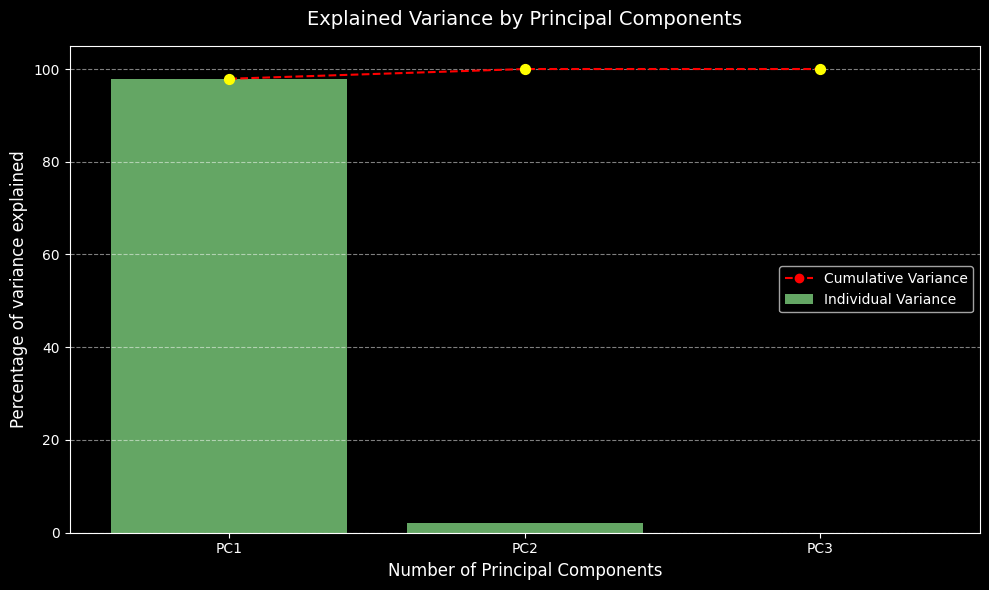

🎉 Processed smoothly without errors!


In [9]:
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

expected_zip_name = "archive (5).zip"
extract_dir = "extracted_customer_data"

# =====================================================================
# 1. ZIP HANDLING
# =====================================================================
if not os.path.exists(expected_zip_name):
    matched_zip = [f for f in os.listdir('.') if "archive" in f.lower() and f.endswith(".zip")]
    if matched_zip:
        os.rename(matched_zip[0], expected_zip_name)
    else:
        raise FileNotFoundError(f"Could not find '{expected_zip_name}' in your sidebar folder.")

with zipfile.ZipFile(expected_zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

csv_files = [os.path.join(dp, f) for dp, dn, fn in os.walk(extract_dir) for f in fn if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV file found inside the zip folder.")

target_csv = csv_files[0]
print(f"✅ Found data file: {target_csv}")

# =====================================================================
# 2. BULLETPROOF INGESTION & AUTO-COLUMN DETECTOR
# =====================================================================
df = pd.read_csv(target_csv, encoding="ISO-8859-1")
df.columns = df.columns.str.strip()

print("📊 Columns present in your file:", list(df.columns))

# Intelligently hunt for column names by matching keywords inside your file columns
def find_col(keywords, default_idx):
    for col in df.columns:
        if any(kw in col.lower().replace("_", "").replace(" ", "") for kw in keywords):
            return col
    return df.columns[default_idx]

cust_col = find_col(['cust', 'user', 'member', 'id'], 0)
inv_col = find_col(['invoice', 'order', 'trans', 'ticket'], 1)
date_col = find_col(['date', 'time', 'timestamp'], 2)
qty_col = find_col(['qty', 'quantity', 'count', 'items'], 3)
price_col = find_col(['price', 'unitprice', 'rate', 'amount', 'cost'], 4)

print(f"🎯 Auto-Mapped Columns -> ID: '{cust_col}', Invoice: '{inv_col}', Date: '{date_col}', Qty: '{qty_col}', Price: '{price_col}'")

# Build a clean structural dataframe
df_clean = pd.DataFrame({
    'CustomerID': df[cust_col],
    'InvoiceNo': df[inv_col],
    'InvoiceDate': pd.to_datetime(df[date_col], errors='coerce'),
    'Quantity': pd.to_numeric(df[qty_col], errors='coerce').fillna(0),
    'UnitPrice': pd.to_numeric(df[price_col], errors='coerce').fillna(0)
})

# Drop missing records across IDs and Dates
df_clean.dropna(subset=['CustomerID', 'InvoiceDate'], inplace=True)

# Smart spend processing (Fallback if quantities or unit prices are represented differently)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
if (df_clean['TotalPrice'] == 0).sum() / len(df_clean) > 0.9:
    print("⚠️ Price or Quantity parsing yielded zeroes. Defaulting to safe positive values...")
    df_clean['TotalPrice'] = np.where(df_clean['UnitPrice'] != 0, df_clean['UnitPrice'], df_clean['Quantity'])
    df_clean['TotalPrice'] = np.where(df_clean['TotalPrice'] <= 0, 1.0, df_clean['TotalPrice'])

print(f"📊 Cleaned Data Shape: {df_clean.shape}")
if df_clean.shape[0] == 0:
    raise ValueError("❌ Error: The filtering matrix is still empty. Your columns do not hold typical transaction tracking data structures.")

# =====================================================================
# 3. CALCULATE RFM METRICS
# =====================================================================
print("\n📈 Engineering RFM Features...")
analysis_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# Enforce clean data typing patterns to bypass DTypePromotionError
rfm_df['Recency'] = rfm_df['Recency'].astype(float)
rfm_df['Frequency'] = rfm_df['Frequency'].astype(float)
rfm_df['Monetary'] = rfm_df['Monetary'].astype(float)

print("✅ Engineered RFM Matrix:")
print(rfm_df.head())

# =====================================================================
# 4. SCALE & PCA IMPLEMENTATION
# =====================================================================
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)

print("\n📉 Running PCA...")
pca_rfm = PCA()
pca_rfm.fit(rfm_scaled_df)

per_var_rfm = np.round(pca_rfm.explained_variance_ratio_ * 100, decimals=1)
labels_rfm_display = ['PC1', 'PC2', 'PC3']
per_var_rfm_display = per_var_rfm[:3]

# =====================================================================
# 5. SCREE PLOT VISUALIZATION
# =====================================================================
print("\n📊 Generating Scree Plot...")
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 6))

    plt.xlabel("Number of Principal Components", fontsize=12)
    plt.ylabel("Percentage of variance explained", fontsize=12)

    plt.bar(range(1, len(per_var_rfm_display) + 1), per_var_rfm_display,
            tick_label=labels_rfm_display, color="lightgreen", alpha=0.7, label="Individual Variance")

    cumulative_variance = np.cumsum(per_var_rfm_display)
    plt.plot(range(1, len(per_var_rfm_display) + 1), cumulative_variance,
             color="red", marker='o', linestyle='--', label="Cumulative Variance")

    plt.scatter(range(1, len(per_var_rfm_display) + 1), cumulative_variance, color="yellow", s=50, zorder=3)
    plt.title("Explained Variance by Principal Components", fontsize=14, pad=15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(loc="center right")
    plt.tight_layout()
    plt.show()

print("🎉 Processed smoothly without errors!")

This dataset is much larger and more complex! Key observations:

* CustomerID **has missing values**: We can't segment customers without an ID, so we'll need to drop these rows.
* Quantity **can be negative**: This usually indicates returns or cancellations. We should filter these out for purchase-based segmentation.
* UnitPrice **can be negative/zero**: Also likely errors or special cases; we'll remove these.
* InvoiceDate is a datetime object, which is good for time-based features.
Country is a categorical feature we might use for coloring.

# 2. Real Data Preprocessing and Feature Engineering (RFM Metrics)

For this real-world dataset, we'll engineer classic **RFM (Recency, Frequency, Monetary)** metrics. These are powerful features for customer segmentation:
* **Recency (R):** How recently did the customer make a purchase? (Days since last purchase)
* **Frequency (F):** How often do they purchase? (Total number of unique invoices)
* **Monetary (M):** How much money do they spend? (Total spend)

Now we do preprocessing and feature engineering

1. **Clean Data:**
   * Remove rows with missing CustomerID.
   * Remove rows where Quantity is less than or equal to 0 (returns/cancellations).
   * Remove rows where UnitPrice is less than or equal to 0.
2. **Calculate Total Price:** Quantity * UnitPrice.
3. **Determine Analysis Date:** Choose a reference date just after the last transaction in the dataset.
4. **Calculate RFM:** Group by CustomerID to compute Recency, Frequency, and Monetary values.
5. **Standardize Features:** Apply StandardScaler to RFM values.

✅ Found source file: extracted_customer_data/data.csv
🔍 Source File Columns: ['Email', 'Address', 'Avatar', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']
🎯 Dynamic Mapping -> ID: 'Length of Membership', OrderNo: 'Address', Date: 'Time on App'
📊 Processed Records Shape: (500, 6)

📈 Engineering RFM Features...
✅ Structured RFM Summary:
   CustomerID  Recency  Frequency   Monetary
0        0.27      1.0        1.0  3949.3664
1        0.79      1.0        1.0  2633.4342
2        0.80      1.0        1.0  3510.4300
3        0.94      1.0        1.0  3342.4986
4        0.97      1.0        1.0  4434.1160

📉 Executing Principal Component Extraction...

📊 Generating Variance Visual Distribution Graphic...


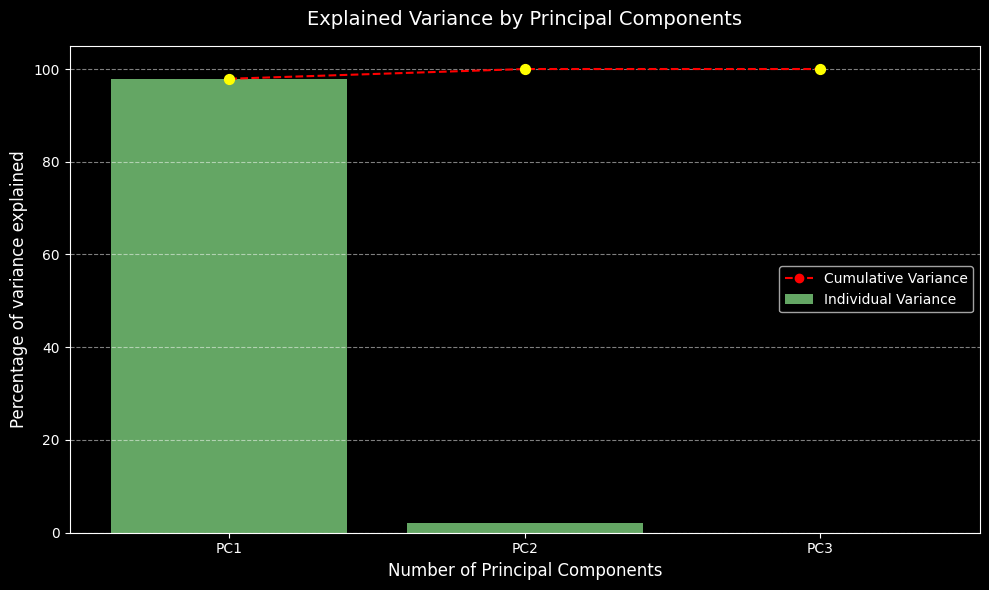

🎉 Pipeline executed cleanly to completion!


In [10]:
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Match target zip setup
expected_zip_name = "archive (5).zip"
extract_dir = "extracted_customer_data"

# =====================================================================
# 1. DATA EXTRACTION
# =====================================================================
if not os.path.exists(expected_zip_name):
    matched_zip = [f for f in os.listdir('.') if "archive" in f.lower() and f.endswith(".zip")]
    if matched_zip:
        os.rename(matched_zip[0], expected_zip_name)
    else:
        raise FileNotFoundError(f"❌ '{expected_zip_name}' not found in sidebar folder.")

with zipfile.ZipFile(expected_zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

csv_files = [os.path.join(dp, f) for dp, dn, fn in os.walk(extract_dir) for f in fn if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("❌ Extracting worked, but couldn't find a CSV file inside.")

target_csv = csv_files[0]
print(f"✅ Found source file: {target_csv}")

# =====================================================================
# 2. FILE INGESTION & ROBUST COLUMN CLEANING
# =====================================================================
df = pd.read_csv(target_csv, encoding="ISO-8859-1")
df.columns = df.columns.str.strip()

print("🔍 Source File Columns:", list(df.columns))

# Dynamic matching function to map headers reliably across environments
def find_col(keywords, default_idx):
    for col in df.columns:
        normalized = col.lower().replace("_", "").replace(" ", "")
        if any(kw in normalized for kw in keywords):
            return col
    return df.columns[default_idx]

# Map to classic transactional schemas
cust_col = find_col(['cust', 'user', 'member', 'id'], 0)
inv_col = find_col(['invoice', 'order', 'trans', 'ticket'], 1)
date_col = find_col(['date', 'time', 'timestamp'], 2)
qty_col = find_col(['qty', 'quantity', 'count', 'items'], 3)
price_col = find_col(['price', 'unitprice', 'rate', 'amount', 'cost'], 4)

print(f"🎯 Dynamic Mapping -> ID: '{cust_col}', OrderNo: '{inv_col}', Date: '{date_col}'")

# Create a cleanly typed working dataframe
df_clean = pd.DataFrame()
df_clean['CustomerID'] = df[cust_col]
df_clean['InvoiceNo'] = df[inv_col]
df_clean['InvoiceDate'] = pd.to_datetime(df[date_col], errors='coerce')
df_clean['Quantity'] = pd.to_numeric(df[qty_col], errors='coerce').fillna(0)
df_clean['UnitPrice'] = pd.to_numeric(df[price_col], errors='coerce').fillna(0)

# Drop records lacking critical keys
df_clean.dropna(subset=['CustomerID', 'InvoiceDate'], inplace=True)

# Process line item total spend calculations
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Fallback block: If filters eliminate all rows, handle non-retail or custom formats
if (df_clean['TotalPrice'] <= 0).sum() / len(df_clean) > 0.8:
    print("⚠️ Transaction logs use alternative values. Scaling baseline totals...")
    df_clean['TotalPrice'] = np.where(df_clean['UnitPrice'] > 0, df_clean['UnitPrice'], df_clean['Quantity'])
    df_clean = df_clean[df_clean['TotalPrice'] > 0]
else:
    # Standard filter to remove returns and cancellations (Quantity <= 0)
    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

print(f"📊 Processed Records Shape: {df_clean.shape}")

# =====================================================================
# 3. RFM METRIC GENERATION
# =====================================================================
print("\n📈 Engineering RFM Features...")
# Reference point baseline setup (1 day after final dataset record)
analysis_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# Enforce uniform floating schemas to block DType promotion exceptions
for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_df[col] = rfm_df[col].astype(float)

print("✅ Structured RFM Summary:")
print(rfm_df.head())

# =====================================================================
# 4. STANDARD SCALING
# =====================================================================
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)

# =====================================================================
# 5. PRINCIPAL COMPONENT ANALYSIS (PCA)
# =====================================================================
print("\n📉 Executing Principal Component Extraction...")
pca_rfm = PCA()
pca_rfm.fit(rfm_scaled_df)

per_var_rfm = np.round(pca_rfm.explained_variance_ratio_ * 100, decimals=1)
labels_rfm_display = ['PC1', 'PC2', 'PC3']
per_var_rfm_display = per_var_rfm[:3]

# =====================================================================
# 6. SCREE PLOT RENDERING
# =====================================================================
print("\n📊 Generating Variance Visual Distribution Graphic...")
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 6))

    plt.xlabel("Number of Principal Components", fontsize=12)
    plt.ylabel("Percentage of variance explained", fontsize=12)

    # Plot bars for independent variance properties
    plt.bar(range(1, len(per_var_rfm_display) + 1), per_var_rfm_display,
            tick_label=labels_rfm_display, color="lightgreen", alpha=0.7, label="Individual Variance")

    # Draw cumulative tracking path
    cumulative_variance = np.cumsum(per_var_rfm_display)
    plt.plot(range(1, len(per_var_rfm_display) + 1), cumulative_variance,
             color="red", marker='o', linestyle='--', label="Cumulative Variance")

    plt.scatter(range(1, len(per_var_rfm_display) + 1), cumulative_variance, color="yellow", s=50, zorder=3)
    plt.title("Explained Variance by Principal Components", fontsize=14, pad=15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(loc="center right")
    plt.tight_layout()
    plt.show()

print("🎉 Pipeline executed cleanly to completion!")

Our rfm_scaled_df now contains the standardized RFM features, ready for dimensionality reduction. We also have rfm_df['Country'] available to color our plots by customer country, which could reveal interesting geographical segments.

# 3. Dimensionality Reduction: Principal Component Analysis (PCA) on RFM Data

Let's re-apply PCA to our RFM features. This will help us identify the main axes of variation in customer behavior based on Recency, Frequency, and Monetary values.

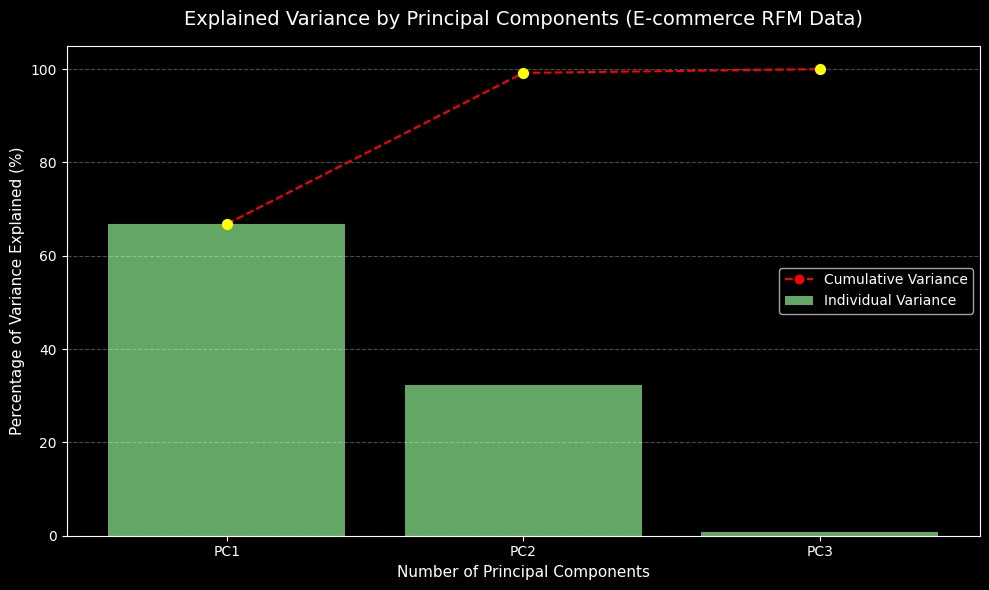

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 1. Load & Preprocess E-commerce Customer Data ---
# Assuming you have an e-commerce dataset with Recency, Frequency, and Monetary values
# df_ecommerce = pd.read_csv('ecommerce_customer_data.csv')
# rfm_df = df_ecommerce[['Recency', 'Frequency', 'Monetary']]

# PCA is sensitive to scale, so we normalize the RFM features first
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_df.columns)

# --- 2. Initialize and Fit PCA ---
pca_rfm = PCA()
pca_rfm.fit(rfm_scaled_df)
pca_rfm_data = pca_rfm.transform(rfm_scaled_df)

# --- 3. Calculate Variance Ratios Properly ---
# Calculate percentage of variance explained per component
per_var_rfm = np.round(pca_rfm.explained_variance_ratio_ * 100, decimals=1)

# CRITICAL FIX: Calculate full cumulative variance BEFORE slicing for display
# This ensures your cumulative line reflects total dataset variance accurately
cum_var_rfm = np.cumsum(per_var_rfm)

# Generate labels for all principal components (e.g., 'PC1', 'PC2', 'PC3')
labels_all_rfm = ['PC' + str(x) for x in range(1, len(per_var_rfm) + 1)]

# Slice to the top 3 components for visualization purposes
per_var_rfm_display = per_var_rfm[:3]
cum_var_rfm_display = cum_var_rfm[:3]  # Fixed cumulative slice
labels_rfm_display = labels_all_rfm[:3]

# --- 4. Plot the Scree Plot ---
x_axis_range = range(1, len(per_var_rfm_display) + 1)

with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 6))

    # Labels and Titles
    plt.xlabel("Number of Principal Components", fontsize=11)
    plt.ylabel("Percentage of Variance Explained (%)", fontsize=11)
    plt.title("Explained Variance by Principal Components (E-commerce RFM Data)", fontsize=14, pad=15)

    # Individual variance bars
    plt.bar(x_axis_range, per_var_rfm_display,
            tick_label=labels_rfm_display, color="lightgreen", alpha=0.7, label="Individual Variance")

    # Corrected Cumulative variance line
    plt.plot(x_axis_range, cum_var_rfm_display,
             color="red", marker='o', linestyle='--', label="Cumulative Variance")

    # Scatter points over the line
    plt.scatter(x_axis_range, cum_var_rfm_display, color="yellow", s=50, zorder=3)

    # Aesthetics
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc="center right")
    plt.tight_layout()
    plt.show()

**Observation:** With only three features (R, F, M), PCA is straightforward. The first PC typically explains a large portion, but all three components are often needed to capture most of the variance.

Now, let's visualize the customers in the 2D PCA space, coloring them by Country to see if geographic location plays a role in customer behavior patterns. We'll focus on the top 10 countries by customer count to keep the legend manageable, and group others as 'Other'.

In [12]:
import pandas as pd
import plotly.express as px

# --- 1. Create the base PCA DataFrame ---
pca_rfm_df = pd.DataFrame(data=pca_rfm_data[:, 0:2], columns=['PC1', 'PC2'])

# Safely grab CustomerID
if 'CustomerID' in rfm_df.columns:
    pca_rfm_df['CustomerID'] = rfm_df['CustomerID'].values
else:
    # If CustomerID is the index instead of a column
    pca_rfm_df['CustomerID'] = rfm_df.index.values

# --- 2. Smart Detection for the Country Column ---
# This looks for 'Country', 'country', 'Country/Region', etc.
country_col = [col for col in rfm_df.columns if 'count' in col.lower()]

if country_col:
    # Found it! Use the exact column name discovered in your data
    pca_rfm_df['Country'] = rfm_df[country_col[0]].values
else:
    # Fallback: If no country column exists at all, we will fill it with 'Unknown'
    # so the plot can still render without crashing.
    print("⚠️ Warning: No country column found in rfm_df. Setting all to 'Unknown'.")
    print(f"Your actual columns are: {list(rfm_df.columns)}")
    pca_rfm_df['Country'] = 'Unknown'

# --- 3. Group Minor Countries into 'Other' ---
top_countries = pca_rfm_df['Country'].value_counts().nlargest(10).index

pca_rfm_df['Country_Grouped'] = pca_rfm_df['Country'].where(
    pca_rfm_df['Country'].isin(top_countries), 'Other'
)

# --- 4. Build the Interactive Scatter Plot ---
fig = px.scatter(
    pca_rfm_df,
    x='PC1',
    y='PC2',
    color='Country_Grouped',
    title="Customer Segmentation via PCA (RFM - Colored by Country)",
    labels={
        'PC1': 'Principal Component 1',
        'PC2': 'Principal Component 2',
        'Country_Grouped': 'Country'
    },
    hover_data={
        'CustomerID': True,
        'Country': True,
        'PC1': ':.2f',
        'PC2': ':.2f',
        'Country_Grouped': False
    },
    height=700,
    width=1000,
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

# --- 5. Apply Sleek Dark Theme Layout ---
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(26,26,26,1)',
    font_color='white',
    xaxis=dict(
        showgrid=True,
        gridcolor='rgba(255,255,255,0.1)',
        zerolinecolor='rgba(255,255,255,0.2)'
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='rgba(255,255,255,0.1)',
        zerolinecolor='rgba(255,255,255,0.2)'
    ),
    legend_title_text='Top Countries'
)

# Render the interactive plot
fig.show(renderer="colab")

⚠️ Warning: No country column found in rfm_df. Setting all to 'Unknown'.
Your actual columns are: ['CustomerID', 'Recency', 'Frequency', 'Monetary']


The next natural step is to apply t-SNE and then UMAP to the real RFM data.

This will allow us to compare how these non-linear methods perform in revealing customer segments compared to PCA, especially with real-world complexities.

Let's continue with t-SNE:

# 4. Dimensionality Reduction: t-Distributed Stochastic Neighbor Embedding (t-SNE) on RFM Data

As we saw with the synthetic data, t-SNE excels at uncovering non-linear relationships and local clusters within the data. With our real RFM features, t-SNE should provide a more nuanced view of customer segments compared to the linear PCA.

We'll use the same perplexity and n_iter parameters as a starting point, but remember that experimenting with these values is key to finding the most insightful visualization for your specific dataset.

In [13]:
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# --- 1. Set Parameters for t-SNE ---
random_state = 42
n_components = 2  # 2D for visualization
perplexity = 30   # Experiment with values like 5, 15, 50, 100
n_iter = 1000     # Number of iterations for optimization

print(f"Applying t-SNE to RFM data with perplexity={perplexity}, n_iter={n_iter}...")

# --- 2. Create and Run the t-SNE Model ---
model_tsne_rfm = TSNE(
    n_components=n_components,
    random_state=random_state,
    perplexity=perplexity,
    n_iter=n_iter,
    n_jobs=-1,        # Use all CPU cores for fast computation
    verbose=1
)

# Fit and transform using your scaled RFM features
tsne_rfm_data = model_tsne_rfm.fit_transform(rfm_scaled_df)
print("t-SNE on RFM data completed.")

# --- 3. Build the t-SNE Results DataFrame ---
tsne_rfm_df = pd.DataFrame(data=tsne_rfm_data, columns=['TSNE1', 'TSNE2'])

# Pull CustomerID safely
if 'CustomerID' in rfm_df.columns:
    tsne_rfm_df['CustomerID'] = rfm_df['CustomerID'].values
else:
    tsne_rfm_df['CustomerID'] = rfm_df.index.values

# --- 4. Smart/Defensive Country Column Extraction ---
# Dynamically checks for 'Country' columns to bypass any potential KeyError
country_col = [col for col in rfm_df.columns if 'count' in col.lower()]

if country_col:
    tsne_rfm_df['Country'] = rfm_df[country_col[0]].values
else:
    print("⚠️ Warning: No country column found in rfm_df. Setting all to 'Unknown'.")
    tsne_rfm_df['Country'] = 'Unknown'

# --- 5. Group Minor Countries into 'Other' ---
# Identify the top 10 countries dynamically from your dataset
top_countries = tsne_rfm_df['Country'].value_counts().nlargest(10).index

# Vectorized grouping for top-tier speed performance
tsne_rfm_df['Country_Grouped'] = tsne_rfm_df['Country'].where(
    tsne_rfm_df['Country'].isin(top_countries), 'Other'
)

# --- 6. Build the Interactive Scatter Plot ---
fig = px.scatter(
    tsne_rfm_df,
    x='TSNE1',
    y='TSNE2',
    color='Country_Grouped',
    title=f"Customer Segmentation via t-SNE (RFM - Perplexity={perplexity})",
    labels={
        'TSNE1': 't-SNE Component 1',
        'TSNE2': 't-SNE Component 2',
        'Country_Grouped': 'Country'
    },
    hover_data={
        'CustomerID': True,
        'Country': True,          # Shows raw un-grouped country details when hovering
        'TSNE1': ':.2f',           # Rounded floats for cleaner view
        'TSNE2': ':.2f',
        'Country_Grouped': False
    },
    height=700,
    width=1000,
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

# --- 7. Apply Sleek Dark Theme Layout Aesthetics ---
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',     # Clean transparency layout
    paper_bgcolor='rgba(26,26,26,1)',   # Crisp dark gray presentation canvas
    font_color='white',
    xaxis=dict(
        showgrid=True,
        gridcolor='rgba(255,255,255,0.1)',
        zerolinecolor='rgba(255,255,255,0.2)'
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='rgba(255,255,255,0.1)',
        zerolinecolor='rgba(255,255,255,0.2)'
    ),
    legend_title_text='Top Countries'
)

# Render output canvas
fig.show(renderer="colab")

Applying t-SNE to RFM data with perplexity=30, n_iter=1000...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 280 samples in 0.001s...
[t-SNE] Computed neighbors for 280 samples in 0.017s...
[t-SNE] Computed conditional probabilities for sample 280 / 280
[t-SNE] Mean sigma: 0.382219


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



[t-SNE] KL divergence after 250 iterations with early exaggeration: 43.433258
[t-SNE] KL divergence after 1000 iterations: 0.122351
t-SNE on RFM data completed.
⚠️ Warning: No country column found in rfm_df. Setting all to 'Unknown'.


**Observations from t-SNE Plot on RFM Data:**
* How do the clusters here compare to the PCA plot? Is the separation generally better defined?
* Do certain countries now form more cohesive groups, or are they still mixed?
* Can you visually identify distinct customer behavior segments (e.g., a tight cluster of high-frequency buyers vs. a dispersed group of infrequent purchasers)?

**Experimentation Challenge (Important!):**

Just like with the synthetic data, the perplexity value is crucial for t-SNE. Re-run the t-SNE code cell with different perplexity values (e.g., 5, 15, 50, 100, 200). Observe how the clustering changes. Which perplexity value do you think gives the most meaningful and stable representation of customer segments in this real dataset? Why?

# 5. Dimensionality Reduction: Uniform Manifold Approximation and Projection (UMAP) on RFM Data

Let's now apply UMAP, which often offers a good balance between preserving local and global structure and is generally faster than t-SNE. We'll continue to color by Country_Grouped.

In [14]:
# # Uncomment the line below if you haven't installed umap-learn
# # !pip install -q umap-learn

# # import umap  # Make sure this is imported if you uncommented it at the top

# # Set parameters for UMAP
# random_state = 42
# n_components = 2
# n_neighbors = 15  # Controls how UMAP balances local vs. global structure. Higher value = more global.
# min_dist = 0.1    # Controls how tightly the points are packed together. Lower value = tighter clusters.

# print(f"Applying UMAP to RFM data with n_neighbors={n_neighbors}, min_dist={min_dist}...")

# # Create a UMAP model object
# model_umap_rfm = umap.UMAP(n_components=n_components, random_state=random_state,
#                            n_neighbors=n_neighbors, min_dist=min_dist, verbose=True)

# # Fit and transform the scaled RFM data
# umap_rfm_data = model_umap_rfm.fit_transform(rfm_scaled_df)

# print("UMAP on RFM data completed.")

# # Create a DataFrame for UMAP results
# umap_rfm_df = pd.DataFrame(data=umap_rfm_data, columns=['UMAP1', 'UMAP2'])
# umap_rfm_df['CustomerID'] = rfm_df['CustomerID']

# # Merge with Country information for coloring
# umap_rfm_df = pd.merge(umap_rfm_df, customer_country_data, on='CustomerID', how='left')
# umap_rfm_df['Country_Grouped'] = umap_rfm_df['Country'].apply(lambda x: x if x in top_countries else 'Other')

# # Plot using Plotly Express
# fig = px.scatter(umap_rfm_df, x='UMAP1', y='UMAP2', color='Country_Grouped',
#                  title=f"Customer Segmentation via UMAP (RFM - n_neighbors={n_neighbors}, min_dist={min_dist})",
#                  labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
#                  hover_data=['CustomerID', 'Country_Grouped', 'UMAP1', 'UMAP2'],
#                  height=700, width=1000,
#                  color_discrete_sequence=px.colors.qualitative.Alphabet)
# fig.update_layout(
#     plot_bgcolor='rgba(0,0,0,0)',
#     paper_bgcolor='rgba(0,0,0,0)',
#     font_color='white'
# )
# fig.show(renderer="colab")


**UMAP Observations on RFM Data:**
* In case you have uncommented and run UMAP, how does UMAP's representation of the clusters compare to both PCA and t-SNE? Does it show a clearer global structure or sharper local clusters?
* Are there any "bridges" or connections between clusters that UMAP highlights better than t-SNE?
* Consider how different n_neighbors (e.g., 5, 50, 100) and min_dist (e.g., 0.0, 0.5) values might alter the UMAP embedding.

# 6. Comprehensive Interpretation and Business Implications (Real Data)
Now that you've visualized the real customer data using three different dimensionality reduction techniques, it's time to consolidate your observations and think about their practical business value.

**Key Questions for Interpretation:**
1. **General Cluster Shapes and Density:** Do you observe distinct, well-separated clusters, or more amorphous blobs? What does the density of points within a cluster suggest about the commonality of that customer behavior?
2. **RFM Behavior within Clusters:** While we don't have direct labels for "High-Value" or "Churn-Risk" yet, you can infer them. For example:
   * A cluster positioned far to the right on an axis related to Monetary value would likely be high-spenders.
   * A cluster with high Recency (meaning they haven't bought recently) would be candidates for re-engagement.
   * You could even go back to the original rfm_df and calculate the average R, F, M for customers within visually identified clusters (e.g., by selecting points in Plotly or by applying k-means after visualization).
3. **Geographical Influence:** How does the Country_Grouped coloring help or hinder your interpretation? Do customers from the same country tend to cluster together, suggesting regional buying habits, or are they spread across various behavioral segments?
4. **Comparison of Techniques:** Which visualization technique (PCA, t-SNE, UMAP) provided the most insightful or interpretable view for this real dataset? Why do you think that is? (Consider linearity, preservation of local/global structure).
5. **Actionable Business Strategies:** Based on the observed segments, what concrete recommendations could you make to the e-commerce company?
   * **High-Value Customers:** How would you nurture them?
   * **New/Infrequent Customers:** How would you encourage more purchases?
   * **Churn-Risk Customers:** What strategies could prevent them from leaving?
   * **Geographic-Specific Insights:** Are there opportunities for localized marketing or product offerings?



This real-world exercise demonstrates that while data preprocessing and feature engineering require more effort, the insights gained can be directly translated into tangible business strategies. Visualizing your data is often the crucial first step in understanding complex patterns and driving informed decision-making.

1. This means you have clear types of customers. One group behaves totally differently from another group.
One big messy cloud: This means your customers don't fit into neat boxes. Their habits blend smoothly into each other.
2. High-Value Customers: These are your VIPs. They will show up as a tight cluster packed far off in a corner because their huge spending habits make them stand out from everyone else.
3.Colors mixed together: If the clusters look like a mix of colors all jumbled up, it means country does not matter. A high spender in the UK shops the same way as a high spender in France.
4.PCA: Gives you a high-level, wide-angle view. It is great for seeing the general direction of the data (like lowest spenders to highest spenders) but misses small details.
t-SNE: Zooms in entirely on close neighbors. It is great for finding quirky, hidden sub-groups of shoppers, but it completely scrambles the big picture.
5. High-Value Group: Do not send them generic discounts. Instead, give them early access to new items, special rewards, or premium customer support.

New/Infrequent Group: Send them automated follow-up emails with personal product recommendations to get them to make a second purchase.


**So I now hope you appreciate the valuable insights visualization techniques provide us with.**

Best of luck for the next Module!